# E1 -- Shots finitos, sin ruido

**Objetivo**: ¿cómo se comportan Hur, Wei y Gong (y `cong`, si
`INCLUDE_CONG_IN_E1_E2`) al pasar del simulador analítico de E0 a medición
por shots finitos (256/1024/4096), todavía sin ruido de hardware? La
variable independiente aquí es el **presupuesto de shots**, no el modelo --
se compara cada modelo contra sí mismo a través de los tres presupuestos.

**Cambio de alcance (confirmado 21-sep-2026)**: a diferencia de Quantum
Advantage/E0B/E2, que se quedan en el embudo de "solo el ganador de E0A"
(ver la diapositiva "4. Diseño experimental: cobertura de modelos por
fase" de `presentacion_avance/avance.tex`), E1 amplía su cobertura a los
3 candidatos completos (Hur, Wei, Gong), para acercarse a la cobertura de
4 modelos que el diseño original preveía para benchmark-core. Cong sigue
fuera de esta expansión por decisión explícita: el mismo régimen de shots
ya causó un runaway de ~2437 minutos con Cong antes de excluirlo de E1 la
primera vez.

Solo QCNNs -- las CNN análogas no tienen circuito que medir por shots, se
quedan en el régimen analítico de `E0_quantum_advantage.ipynb`.

Reutiliza sin cambios `qcnn_benchmark.training.train_binary_classifier`
(BCE/Adam/early-stopping) y el mismo criterio estadístico de E0A/E0B --
solo cambia `predict_proba_fn` (viene de
`qcnn_benchmark.execution.make_shots_predict_proba`, que sustituye el
expectation value analítico por una estimación de N shots, incluyendo en
el *gradiente* vía la regla de desplazamiento de parámetro -- ver
`src/qcnn_benchmark/execution/shots.py`).

Incluye `confusion_counts` (tp/fp/fn/tn) desde esta corrida, costo $0
extra sobre `test_acc` -- ver la familia "Predictivas" en
`qcnn_benchmark.metrics`.


In [ ]:
import json
import pathlib
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from qcnn_benchmark.config import load_config
from qcnn_benchmark.data import load_mnist_pool, load_fashion_mnist_pool
from qcnn_benchmark.representations import build_pca_dataset, build_amplitude_dataset
from qcnn_benchmark.models import qcnn_hur, qcnn_wei, qcnn_gong, qcnn_cong
from qcnn_benchmark.training import train_binary_classifier, uniform_pi_init, normal_init
from qcnn_benchmark.execution import make_shots_predict_proba
from qcnn_benchmark.execution.shots import n_trainable_params
from qcnn_benchmark.metrics import batch_accuracy, confusion_counts
from qcnn_benchmark.stats import (
    bootstrap_bca_ci,
    paired_sign_permutation_test,
    holm_correction,
    cohens_dz,
    probability_of_superiority,
)


## 0. INPUTS MANUALES -- completar antes de correr

`WINNER_MODEL`: de `E0A_seleccion_candidato.ipynb`.
`INCLUDE_CONG_IN_E1_E2`: decidido a mano tras ver la evidencia de
`E0B_validez_aportacion.ipynb` (esa fase no lo decide por ti, ver su Sec. 10).


In [ ]:
WINNER_MODEL = "wei"          # <-- de E0A_seleccion_candidato.ipynb, informativo (ver nota abajo)
INCLUDE_CONG_IN_E1_E2 = False  # <-- True/False, decidido tras ver E0B

assert WINNER_MODEL in ("hur", "wei", "gong"), "Completa WINNER_MODEL arriba"
assert isinstance(INCLUDE_CONG_IN_E1_E2, bool), "Completa INCLUDE_CONG_IN_E1_E2 arriba (True o False)"

# Decision confirmada 21-sep-2026: E1 ya no filtra por WINNER_MODEL -- corre
# los 3 candidatos completos (Hur, Wei, Gong) en vez de solo el ganador de
# E0A. Cong sigue fuera de esta expansion (decision explicita: el mismo
# regimen de shots ya causo un runaway de ~2437 min con Cong antes de
# excluirlo de E1 la primera vez). WINNER_MODEL se conserva solo como
# metadato informativo en el provenance, ya no determina MODELS_TO_RUN.
MODELS_TO_RUN = ["hur", "wei", "gong"] + (["cong"] if INCLUDE_CONG_IN_E1_E2 else [])
print("MODELS_TO_RUN:", MODELS_TO_RUN)


## 1. Configuración declarativa

In [9]:
FAST_SMOKE_TEST = False  # True = 2 semillas, pocas actualizaciones, 1 presupuesto de shots -- solo para validar el pipeline

_CONFIG_CANDIDATES = [pathlib.Path("configs/e1.yaml"), pathlib.Path("../configs/e1.yaml")]
CONFIG_PATH = next(p for p in _CONFIG_CANDIDATES if p.exists())
config = load_config(CONFIG_PATH)

config = config.model_copy(update={"models": MODELS_TO_RUN})

if FAST_SMOKE_TEST:
    config = config.model_copy(update={
        "n_seeds": 2,
        "shots_budgets": [256],
        "protocol": config.protocol.model_copy(update={"n_updates": 10, "val_check_every": 5, "patience_checks": 2}),
    })

print("experiment_id:", config.experiment_id)
print("canonical_hash:", config.canonical_hash(), "(FAST_SMOKE_TEST)" if FAST_SMOKE_TEST else "")
print("datasets:", [d.name for d in config.datasets])
print("models:", config.models)
print("shots_budgets:", config.shots_budgets)
print("run_seeds:", config.run_seeds())


experiment_id: E1_FINITE_SHOTS
canonical_hash: c2ee95d45e65 
datasets: ['coat_vs_shirt', '4_vs_9', '1_vs_0']
models: ['wei']
shots_budgets: [256, 1024, 4096]
run_seeds: [0, 1, 2, 3, 4]


## 2. Estimación de costo de cómputo

**Referencia REAL medida (18-sep-2026), no backprop escalado**: sonda de 3
actualizaciones de gradiente reales, datos reales, shots=256 (el
presupuesto más barato de los 3), batch=25 (protocolo real de este
notebook) -- ver la diapositiva "10. Próximos pasos (2/3)" de
`presentacion_avance/avance.tex`. La referencia anterior (backprop de
E0A escalado) subestimaba el costo real por un factor de 10-20x: bajo
shots, PennyLane usa parameter-shift (∼2×n_params pasadas por gradiente)
en vez de backprop (1 pasada), y ese costo domina.

Hur y Gong son ordenes de magnitud mas caros que Wei bajo este regimen:
Wei diferencia coeficientes de un hamiltoniano de lectura (expansion
lineal barata), Hur y Gong diferencian los parametros del circuito
completo via parameter-shift.


In [ ]:
# Segundos/actualizacion MEDIDOS (no estimados por escalado):
# - hur, gong: sonda de 3 actualizaciones reales, 18-sep-2026, shots=256, batch=25 (ver Sec. 2)
# - wei: promedio limpio de las primeras 3 semillas de la corrida ya completada
#   de este notebook (results/e1_raw_c2ee95d45e65.csv, coat_vs_shirt/shots256),
#   tomado ANTES de un evento de suspension de la maquina que contamino el
#   timestamp acumulado de corridas posteriores en ese CSV (no afecta la
#   exactitud entrenada, solo el "t=Xs acumulado" impreso).
REAL_SEC_PER_UPDATE = {"hur": 62.2, "gong": 21.0, "wei": 0.6}

n_shots_budgets = len(config.shots_budgets)
n_seeds = config.n_seeds
n_datasets = len(config.datasets)

total_sec_measured = sum(
    REAL_SEC_PER_UPDATE[m] * config.protocol.n_updates * n_shots_budgets * n_seeds * n_datasets
    for m in config.models
)

print("Estimación basada en costo REAL medido por actualización (cota superior, asume 0 early stopping):")
print(f"  {n_shots_budgets} presupuestos de shots x {n_seeds} semillas x {n_datasets} datasets x "
      f"{config.protocol.n_updates} actualizaciones x {len(config.models)} modelo(s)")
print(f"  ~{total_sec_measured/3600:.0f} h (~{total_sec_measured/86400:.1f} dias) combinado\n")
for m in config.models:
    per_model = REAL_SEC_PER_UPDATE[m] * config.protocol.n_updates * n_shots_budgets * n_seeds * n_datasets
    print(f"  {m}: ~{per_model/3600:.1f} h (~{per_model/86400:.2f} dias)")
print()
print("En la practica el early stopping reduce esto algo (la corrida ya completada")
print("de wei detuvo la mayoria de sus corridas antes de las 500 actualizaciones),")
print("pero no cambia el orden de magnitud: correr esta matriz completa toma dias,")
print("no horas, para hur y gong.")


## 3. Registro de modelos y representaciones

In [11]:
MODEL_REGISTRY = {
    "hur": {"module": qcnn_hur, "init": uniform_pi_init, "normalize": True,
            "build_rep": lambda x, y, pos, neg: build_pca_dataset(x, y, pos, neg, n_components=16, verbose=False)},
    "wei": {"module": qcnn_wei, "init": normal_init, "normalize": False,
            "build_rep": lambda x, y, pos, neg: build_amplitude_dataset(x, y, pos, neg, verbose=False)},
    "gong": {"module": qcnn_gong, "init": uniform_pi_init, "normalize": True,
             "build_rep": lambda x, y, pos, neg: build_pca_dataset(x, y, pos, neg, n_components=8, verbose=False)},
    "cong": {"module": qcnn_cong, "init": uniform_pi_init, "normalize": True,
             "build_rep": lambda x, y, pos, neg: build_pca_dataset(x, y, pos, neg, n_components=8, verbose=False)},
}

_POOL_CACHE = {}


def get_pool(source, normalize):
    key = (source, normalize)
    if key not in _POOL_CACHE:
        loader = load_mnist_pool if source == "mnist" else load_fashion_mnist_pool
        _POOL_CACHE[key] = loader(normalize=normalize)
    return _POOL_CACHE[key]


## 4. Ejecución (matriz: datasets × modelos × presupuestos de shots × semillas)

In [ ]:
RESULTS_DIR = pathlib.Path("results") if pathlib.Path("results").exists() else pathlib.Path("../results")
raw_path = RESULTS_DIR / f"e1_raw_{config.canonical_hash()}.csv"
print("canonical_hash:", config.canonical_hash(), flush=True)
print("models:", config.models, flush=True)
print("raw_path:", raw_path, flush=True)

# Reanudacion: si ya existe un CSV parcial de una corrida que murio a mitad
# de camino (ver incidente 21-sep-2026), no se repiten las combinaciones
# (dataset, modelo, n_shots, semilla) ya presentes.
if raw_path.exists():
    existing_df = pd.read_csv(raw_path)
    rows = existing_df.to_dict("records")
    done_keys = {(r["dataset"], r["model"], r["n_shots"], r["seed"]) for r in rows}
    print(f"Reanudando: {len(rows)} filas ya hechas en {raw_path}, se saltan.", flush=True)
else:
    rows = []
    done_keys = set()

t_start = time.time()
for dataset in config.datasets:
    for model_name in config.models:
        entry = MODEL_REGISTRY[model_name]
        x_all, y_all = get_pool(dataset.source, entry["normalize"])
        rep = entry["build_rep"](x_all, y_all, dataset.class_pos, dataset.class_neg)
        n_params = n_trainable_params(model_name)  # != entry["module"].TOTAL_PARAMS solo para "wei" (ver execution/shots.py)

        for n_shots in config.shots_budgets:
            predict_proba = make_shots_predict_proba(model_name, n_shots)

            for seed in config.run_seeds():
                if (dataset.name, model_name, n_shots, seed) in done_keys:
                    continue
                tag = f"{dataset.name}-{model_name}-shots{n_shots}-seed{seed}"
                # verbose=True (22-sep-2026): antes con False el log quedaba
                # mudo hasta que una corrida ENTERA terminaba, hasta 8.6h en
                # el peor caso para Hur, sin ninguna senal intermedia de vida.
                # Ahora imprime cada val_check_every (10) actualizaciones,
                # con flush=True dentro de training/loop.py.
                result = train_binary_classifier(
                    predict_proba, n_params, rep, entry["init"],
                    run_seed=seed,
                    batch_size=config.protocol.batch_size,
                    n_updates=config.protocol.n_updates,
                    learning_rate=config.protocol.learning_rate,
                    beta1=config.protocol.beta1,
                    beta2=config.protocol.beta2,
                    clip_norm=config.protocol.clip_norm,
                    val_check_every=config.protocol.val_check_every,
                    patience_checks=config.protocol.patience_checks,
                    min_delta=config.protocol.min_delta,
                    verbose=True,
                    tag=tag,
                )
                train_acc = batch_accuracy(predict_proba, result["params"], rep["X_train"], rep["y_train"])
                test_acc = batch_accuracy(predict_proba, result["params"], rep["X_test"], rep["y_test"])
                # Confusion_counts desde el inicio (costo $0 extra: predict_labels
                # ya se recorre para test_acc) -- ver metrics/__init__.py.
                test_conf = confusion_counts(predict_proba, result["params"], rep["X_test"], rep["y_test"])
                rows.append({
                    "dataset": dataset.name, "model": model_name, "n_shots": n_shots, "seed": seed,
                    "train_acc": train_acc, "test_acc": test_acc,
                    "test_tp": test_conf["tp"], "test_fp": test_conf["fp"],
                    "test_fn": test_conf["fn"], "test_tn": test_conf["tn"],
                    "n_updates_run": result["n_updates_run"], "stopped_early_at": result["stopped_early_at"],
                    "best_val_loss": result["best_val_loss"],
                })
                elapsed = time.time() - t_start
                print(f"[{tag}] test_acc={test_acc:.4f}  (t={elapsed:.0f}s / {elapsed/3600:.1f}h acumulado)",
                      flush=True)

                raw_df = pd.DataFrame(rows)
                raw_df.to_csv(raw_path, index=False)

print("Total:", time.time() - t_start, "s")
raw_df = pd.DataFrame(rows)
raw_df


## 5. Resultados crudos

In [13]:
raw_df = pd.read_csv(raw_path)
display(raw_df)
raw_df.pivot_table(index=["dataset", "model"], columns="n_shots", values="test_acc", aggfunc=list)


,dataset,model,n_shots,seed,train_acc,test_acc,n_updates_run,stopped_early_at,best_val_loss
0,coat_vs_shirt,wei,256,0,0.641,0.632,430,430.0,0.645708
1,coat_vs_shirt,wei,256,1,0.646,0.636,350,350.0,0.649203
2,coat_vs_shirt,wei,256,2,0.632,0.636,380,380.0,0.646814
3,coat_vs_shirt,wei,256,3,0.627,0.632,230,230.0,0.663192
4,coat_vs_shirt,wei,256,4,0.652,0.641,500,500.0,0.640735
5,coat_vs_shirt,wei,1024,0,0.671,0.663,370,370.0,0.646069
6,coat_vs_shirt,wei,1024,1,0.651,0.654,390,390.0,0.640776
7,coat_vs_shirt,wei,1024,2,0.691,0.663,410,410.0,0.638848
8,coat_vs_shirt,wei,1024,3,0.671,0.642,430,430.0,0.640435
9,coat_vs_shirt,wei,1024,4,0.644,0.645,210,210.0,0.659684


,n_shots,256,1024,4096
dataset,model,,,
1_vs_0,wei,"[0.984, 0.988, 0.98, 0.984, 0.985]","[0.986, 0.986, 0.987, 0.987, 0.985]","[0.987, 0.987, 0.986, 0.987, 0.985]"
4_vs_9,wei,"[0.797, 0.802, 0.818, 0.806, 0.812]","[0.845, 0.852, 0.839, 0.826, 0.851]","[0.849, 0.857, 0.846, 0.843, 0.846]"
coat_vs_shirt,wei,"[0.632, 0.636, 0.636, 0.632, 0.641]","[0.663, 0.654, 0.663, 0.642, 0.645]","[0.673, 0.683, 0.683, 0.68, 0.698]"


## 6. Métricas agregadas (media ± IC bootstrap BCa por dataset, modelo y presupuesto de shots)

In [14]:
agg_rows = []
for (dataset_name, model_name, n_shots), group in raw_df.groupby(["dataset", "model", "n_shots"]):
    accs = group["test_acc"].to_numpy()
    lo, hi = bootstrap_bca_ci(
        accs, n_bootstrap=config.statistical_criterion.n_bootstrap,
        confidence_level=config.statistical_criterion.confidence_level,
        rng=np.random.default_rng(0),
    )
    agg_rows.append({
        "dataset": dataset_name, "model": model_name, "n_shots": n_shots,
        "mean_test_acc": float(np.mean(accs)), "ci_lo": lo, "ci_hi": hi, "n_seeds": len(accs),
    })

agg_df = pd.DataFrame(agg_rows)
agg_df


,dataset,model,n_shots,mean_test_acc,ci_lo,ci_hi,n_seeds
0,1_vs_0,wei,256,0.9842,0.9824,0.9866,5
1,1_vs_0,wei,1024,0.9862,0.9856,0.9868,5
2,1_vs_0,wei,4096,0.9864,0.9856,0.9870,5
3,4_vs_9,wei,256,0.8070,0.8008,0.8136,5
4,4_vs_9,wei,1024,0.8426,0.8324,0.8492,5
5,4_vs_9,wei,4096,0.8482,0.8448,0.8538,5
6,coat_vs_shirt,wei,256,0.6354,0.6328,0.6382,5
7,coat_vs_shirt,wei,1024,0.6534,0.6456,0.6612,5
8,coat_vs_shirt,wei,4096,0.6834,0.6778,0.6920,5


## 7. Análisis estadístico (presupuestos de shots entre sí, por modelo y dataset)

Compara cada par de presupuestos de shots (256 vs. 1024, 1024 vs. 4096,
256 vs. 4096) dentro de cada (dataset, modelo) -- no modelos entre sí, esa
comparación ya se hizo en E0A/E0B.


In [15]:
from itertools import combinations

comparison_rows = []
for (dataset_name, model_name), group in raw_df.groupby(["dataset", "model"]):
    pivot = group.pivot(index="seed", columns="n_shots", values="test_acc")
    for shots_a, shots_b in combinations(config.shots_budgets, 2):
        x, y = pivot[shots_a].to_numpy(), pivot[shots_b].to_numpy()
        p_value, mean_diff = paired_sign_permutation_test(
            x, y, n_permutations=config.statistical_criterion.n_bootstrap,
            rng=np.random.default_rng(0),
        )
        comparison_rows.append({
            "dataset": dataset_name, "model": model_name, "shots_a": shots_a, "shots_b": shots_b,
            "mean_diff_a_minus_b": mean_diff, "p_value": p_value,
            "cohens_dz": cohens_dz(x, y), "prob_superiority_a_over_b": probability_of_superiority(x, y),
        })

comparisons_df = pd.DataFrame(comparison_rows)
if len(comparisons_df):
    adjusted, rejected = holm_correction(comparisons_df["p_value"], alpha=config.statistical_criterion.alpha)
    comparisons_df["p_value_holm"] = adjusted
    comparisons_df["significant"] = rejected
else:
    print("Sin comparaciones -- config.shots_budgets tiene menos de 2 valores (normal en FAST_SMOKE_TEST).")
comparisons_df


,dataset,model,shots_a,shots_b,mean_diff_a_minus_b,p_value,cohens_dz,prob_superiority_a_over_b,p_value_holm,significant
0,1_vs_0,wei,256,1024,-0.0020,0.3750,-0.589768,0.3,1.0000,False
1,1_vs_0,wei,256,4096,-0.0022,0.2500,-0.792825,0.3,1.0000,False
2,1_vs_0,wei,1024,4096,-0.0002,1.0000,-0.239046,0.4,1.0000,False
3,4_vs_9,wei,256,1024,-0.0356,0.0625,-2.472580,0.0,0.5625,False
4,4_vs_9,wei,256,4096,-0.0412,0.0625,-3.510995,0.0,0.5625,False
5,4_vs_9,wei,1024,4096,-0.0056,0.2500,-0.712351,0.2,1.0000,False
6,coat_vs_shirt,wei,256,1024,-0.0180,0.0625,-1.594107,0.0,0.5625,False
7,coat_vs_shirt,wei,256,4096,-0.0480,0.0625,-8.355727,0.0,0.5625,False
8,coat_vs_shirt,wei,1024,4096,-0.0300,0.0625,-1.814022,0.0,0.5625,False


## 8. Figuras y tablas

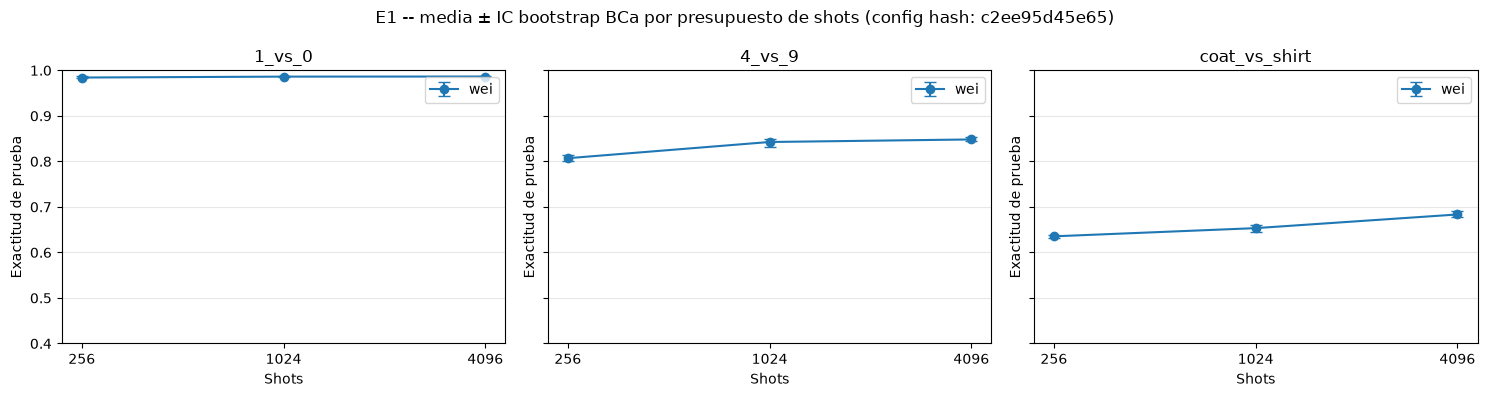

In [16]:
fig, axes = plt.subplots(1, len(config.datasets), figsize=(5 * len(config.datasets), 4), sharey=True)
if len(config.datasets) == 1:
    axes = [axes]
for ax, (dataset_name, group) in zip(axes, agg_df.groupby("dataset")):
    for model_name, model_group in group.groupby("model"):
        model_group = model_group.set_index("n_shots").loc[config.shots_budgets]
        yerr = [model_group["mean_test_acc"] - model_group["ci_lo"], model_group["ci_hi"] - model_group["mean_test_acc"]]
        ax.errorbar(model_group.index.astype(str), model_group["mean_test_acc"], yerr=yerr, marker="o", capsize=4, label=model_name)
    ax.set_title(dataset_name)
    ax.set_xlabel("Shots")
    ax.set_ylabel("Exactitud de prueba")
    ax.set_ylim(0.4, 1.0)
    ax.grid(alpha=0.3, axis="y")
    ax.legend()
plt.suptitle("E1 -- media ± IC bootstrap BCa por presupuesto de shots (config hash: " + config.canonical_hash() + ")")
plt.tight_layout()
plt.show()


In [17]:
if len(comparisons_df):
    display(comparisons_df.style.format({
        "mean_diff_a_minus_b": "{:+.4f}", "p_value": "{:.4f}", "p_value_holm": "{:.4f}",
        "cohens_dz": "{:.2f}", "prob_superiority_a_over_b": "{:.2f}",
    }))


,dataset,model,shots_a,shots_b,mean_diff_a_minus_b,p_value,cohens_dz,prob_superiority_a_over_b,p_value_holm,significant
0,1_vs_0,wei,256,1024,-0.0020,0.3750,-0.59,0.30,1.0000,False
1,1_vs_0,wei,256,4096,-0.0022,0.2500,-0.79,0.30,1.0000,False
2,1_vs_0,wei,1024,4096,-0.0002,1.0000,-0.24,0.40,1.0000,False
3,4_vs_9,wei,256,1024,-0.0356,0.0625,-2.47,0.00,0.5625,False
4,4_vs_9,wei,256,4096,-0.0412,0.0625,-3.51,0.00,0.5625,False
5,4_vs_9,wei,1024,4096,-0.0056,0.2500,-0.71,0.20,1.0000,False
6,coat_vs_shirt,wei,256,1024,-0.0180,0.0625,-1.59,0.00,0.5625,False
7,coat_vs_shirt,wei,256,4096,-0.0480,0.0625,-8.36,0.00,0.5625,False
8,coat_vs_shirt,wei,1024,4096,-0.0300,0.0625,-1.81,0.00,0.5625,False


## 9. Selección / conclusión -- ¿converge la exactitud con más shots?

In [18]:
alpha = config.statistical_criterion.alpha
max_shots = max(config.shots_budgets)
for (dataset_name, model_name), group in agg_df.groupby(["dataset", "model"]):
    group = group.set_index("n_shots").loc[config.shots_budgets]
    print(f"{dataset_name} / {model_name}: " + " -> ".join(f"{s} shots: {group.loc[s, 'mean_test_acc']:.4f}" for s in config.shots_budgets))
    row = comparisons_df[
        (comparisons_df["dataset"] == dataset_name) & (comparisons_df["model"] == model_name)
        & (comparisons_df["shots_a"] == config.shots_budgets[0]) & (comparisons_df["shots_b"] == max_shots)
    ] if len(comparisons_df) else comparisons_df
    if len(row):
        sig = bool(row["significant"].iloc[0])
        print(f"  {config.shots_budgets[0]} vs {max_shots} shots: {'diferencia significativa' if sig else 'sin diferencia significativa'} tras Holm")


1_vs_0 / wei: 256 shots: 0.9842 -> 1024 shots: 0.9862 -> 4096 shots: 0.9864
  256 vs 4096 shots: sin diferencia significativa tras Holm
4_vs_9 / wei: 256 shots: 0.8070 -> 1024 shots: 0.8426 -> 4096 shots: 0.8482
  256 vs 4096 shots: sin diferencia significativa tras Holm
coat_vs_shirt / wei: 256 shots: 0.6354 -> 1024 shots: 0.6534 -> 4096 shots: 0.6834
  256 vs 4096 shots: sin diferencia significativa tras Holm


## 10. Registro de reproducibilidad

In [19]:
import pennylane, sklearn, scipy

provenance = {
    "experiment_id": config.experiment_id,
    "winner_model": WINNER_MODEL,
    "include_cong": INCLUDE_CONG_IN_E1_E2,
    "canonical_hash": config.canonical_hash(),
    "config": json.loads(config.canonical_json()),
    "fast_smoke_test": FAST_SMOKE_TEST,
    "timestamp_utc": pd.Timestamp.utcnow().isoformat(),
    "raw_results_path": str(raw_path),
    "package_versions": {
        "pennylane": pennylane.__version__,
        "numpy": np.__version__,
        "scipy": scipy.__version__,
        "scikit_learn": sklearn.__version__,
        "pandas": pd.__version__,
    },
}

provenance_path = RESULTS_DIR / f"e1_provenance_{config.canonical_hash()}.json"
provenance_path.write_text(json.dumps(provenance, indent=2, ensure_ascii=False))
print("Provenance guardado en:", provenance_path)
print(json.dumps(provenance, indent=2, ensure_ascii=False))


Provenance guardado en: ../results/e1_provenance_c2ee95d45e65.json
{
  "experiment_id": "E1_FINITE_SHOTS",
  "winner_model": "wei",
  "include_cong": false,
  "canonical_hash": "c2ee95d45e65",
  "config": {
    "datasets": [
      {
        "class_neg": 6,
        "class_pos": 4,
        "name": "coat_vs_shirt",
        "source": "fashion_mnist"
      },
      {
        "class_neg": 9,
        "class_pos": 4,
        "name": "4_vs_9",
        "source": "mnist"
      },
      {
        "class_neg": 0,
        "class_pos": 1,
        "name": "1_vs_0",
        "source": "mnist"
      }
    ],
    "description": "¿Cómo se degrada (o no) la exactitud de WINNER_MODEL (y de Cong, si INCLUDE_CONG_IN_E1_E2) al pasar del simulador analítico de E0 a medición por shots finitos, sin ruido de hardware todavía? Compara los tres presupuestos de shots entre sí (no modelos entre sí) sobre los mismos tres datasets y el mismo protocolo de entrenamiento -- el ruido de muestreo también afecta al gradiente d

/var/folders/l9/hx3k3fcs03d6gz71m2n3t1c80000gn/T/ipykernel_4078/3254773348.py:10: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  "timestamp_utc": pd.Timestamp.utcnow().isoformat(),
